In [29]:
# ============================================================
# 1️⃣ IMPORT LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import seaborn as sns
warnings.filterwarnings("ignore")

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, precision_score, recall_score, f1_score, accuracy_score, confusion_matrix

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, SimpleRNN
from tensorflow.keras.callbacks import EarlyStopping

In [30]:
# ============================================================
# 2️⃣ LOAD & PREPROCESS MULTI-YEAR NSE DATASET
# ============================================================

df = pd.read_csv("NIFTY_5_Years.csv", encoding="utf-8-sig")

# Clean columns
df.columns = df.columns.str.strip()

# Convert date
df['Date'] = pd.to_datetime(df['Date'])

# Sort ascending
df = df.sort_values("Date")

# Set index
df.set_index("Date", inplace=True)

# Use Close price
data = df[['Close']]

# Train-Test Split (80-20)
train_size = int(len(data) * 0.8)
train, test = data[:train_size], data[train_size:]

print("Training size:", len(train))
print("Testing size :", len(test))

Training size: 992
Testing size : 248


In [31]:
# ============================================================
# 3️⃣ SCALING FOR DEEP LEARNING
# ============================================================

scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train)
test_scaled = scaler.transform(test)

In [32]:
# ============================================================
# 4️⃣ HELPER FUNCTIONS
# ============================================================

def create_sequences(data, time_steps=60):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:i+time_steps])
        y.append(data[i+time_steps])
    return np.array(X), np.array(y)


def evaluate_model(actual, predicted, name):
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)
    r2 = r2_score(actual, predicted)

    print(f"\n{name}")
    print("RMSE:", rmse)
    print("MAE :", mae)
    print("R2  :", r2)

    return rmse, mae, r2


time_steps = 60

# Traditional Model Codes :

## ARIMA

In [34]:
from statsmodels.tsa.arima.model import ARIMA

# ARIMA Model
arima_model = ARIMA(train['Close'], order=(3,1,1))
arima_result = arima_model.fit()

# Forecast
arima_pred = arima_result.forecast(steps=len(test))

# Align with time_steps
arima_pred = arima_pred[time_steps:].values
actual_arima = test['Close'].values[time_steps:]

# Evaluation
rmse_arima, mae_arima, r2_arima = evaluate_model(actual_arima, arima_pred, "ARIMA")


ARIMA
RMSE: 2484.767033973403
MAE : 2431.371695348688
R2  : -22.52035531231446


## SARIMA

In [35]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# SARIMA Model
sarima_model = SARIMAX(train['Close'],
                       order=(2,1,2),
                       seasonal_order=(1,1,1,12))

sarima_result = sarima_model.fit()

# Forecast
sarima_pred = sarima_result.forecast(steps=len(test))

# Align
sarima_pred = sarima_pred[time_steps:].values
actual_sarima = test['Close'].values[time_steps:]

# Evaluation
rmse_sarima, mae_sarima, r2_sarima = evaluate_model(actual_sarima, sarima_pred, "SARIMA")


SARIMA
RMSE: 667.6502637246325
MAE : 558.0894843706183
R2  : -0.6981285938110069


## LSTM

In [36]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Create sequences
X_train, y_train = create_sequences(train_scaled, time_steps)
X_test, y_test = create_sequences(test_scaled, time_steps)

# LSTM Model
model_lstm = Sequential([
    LSTM(64, activation='relu', input_shape=(time_steps,1)),
    Dense(1)
])

model_lstm.compile(optimizer='adam', loss='mse')

model_lstm.fit(X_train, y_train,
               epochs=40,
               batch_size=32,
               verbose=0)

# Prediction
lstm_pred = model_lstm.predict(X_test)
lstm_pred = scaler.inverse_transform(lstm_pred)

actual_lstm = scaler.inverse_transform(y_test)

# Flatten (IMPORTANT)
lstm_pred = lstm_pred.flatten()
actual_lstm = actual_lstm.flatten()

# Evaluation
rmse_lstm, mae_lstm, r2_lstm = evaluate_model(actual_lstm, lstm_pred, "LSTM")

6/6 [==============================] - 0s 5ms/step

LSTM
RMSE: 441.61005889566695
MAE : 395.6057305518619
R2  : 0.25706564892693595


## RNN

In [37]:
from tensorflow.keras.layers import SimpleRNN

# Create sequences
X_train, y_train = create_sequences(train_scaled, time_steps)
X_test, y_test = create_sequences(test_scaled, time_steps)

# RNN Model
model_rnn = Sequential([
    SimpleRNN(64, input_shape=(time_steps,1)),
    Dense(1)
])

model_rnn.compile(optimizer='adam', loss='mse')

model_rnn.fit(X_train, y_train,
              epochs=40,
              batch_size=32,
              verbose=0)

# Prediction
rnn_pred = model_rnn.predict(X_test)
rnn_pred = scaler.inverse_transform(rnn_pred)

actual_rnn = scaler.inverse_transform(y_test)

# Flatten (IMPORTANT)
rnn_pred = rnn_pred.flatten()
actual_rnn = actual_rnn.flatten()

# Evaluation
rmse_rnn, mae_rnn, r2_rnn = evaluate_model(actual_rnn, rnn_pred, "RNN")

6/6 [==============================] - 0s 3ms/step

RNN
RMSE: 226.3868466391624
MAE : 184.6207613031918
R2  : 0.8047572547604325


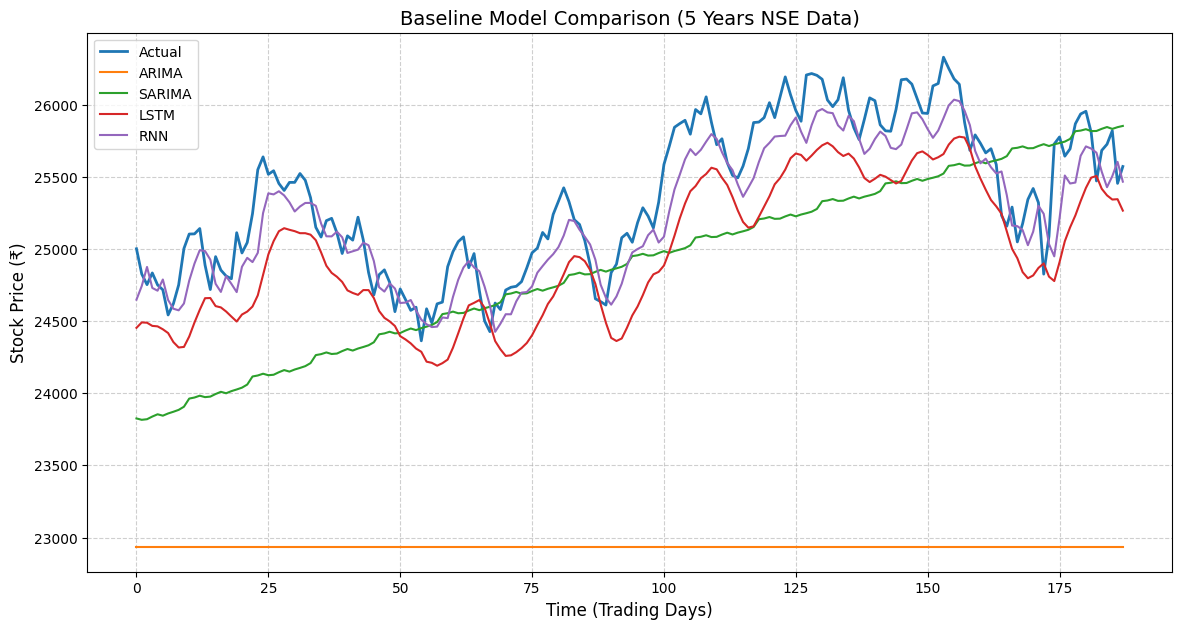

In [38]:
plt.figure(figsize=(14,7))

plt.plot(actual_arima, label="Actual", linewidth=2)
plt.plot(arima_pred, label="ARIMA")
plt.plot(sarima_pred, label="SARIMA")
plt.plot(lstm_pred, label="LSTM")
plt.plot(rnn_pred, label="RNN")

plt.xlabel("Time (Trading Days)", fontsize=12)
plt.ylabel("Stock Price (₹)", fontsize=12)
plt.title("Baseline Model Comparison (5 Years NSE Data)", fontsize=14)

plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

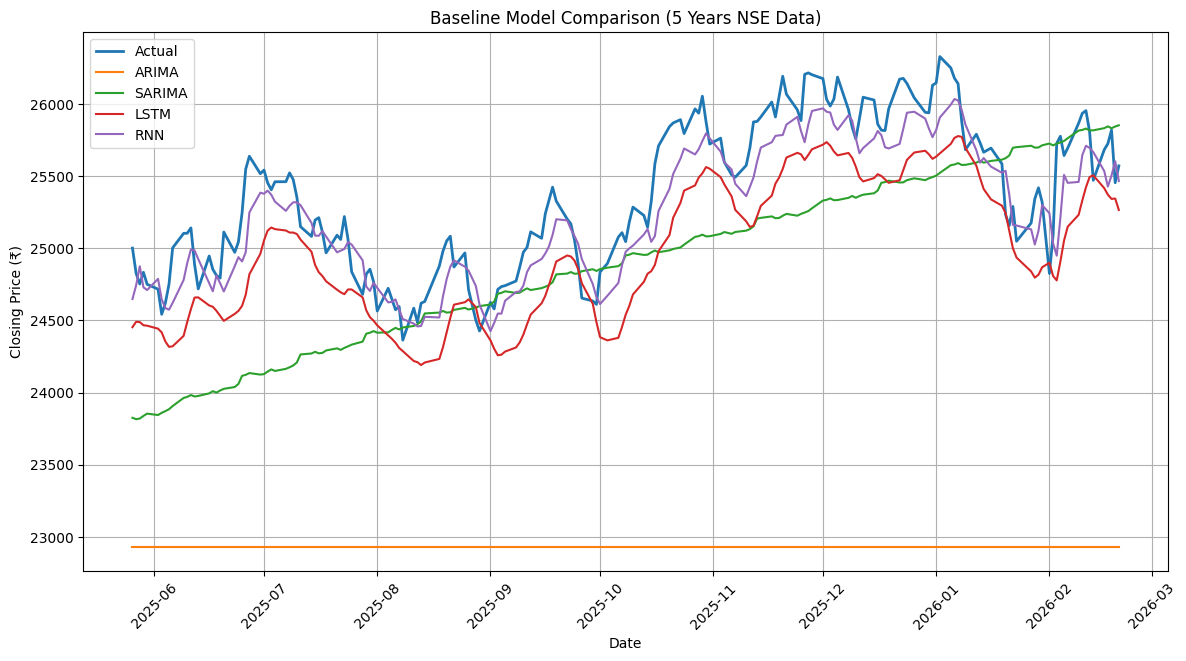

In [39]:
dates = test.index[time_steps:]

# Align predictions
arima_plot = arima_pred.flatten()
sarima_plot = sarima_pred.flatten()
lstm_plot = lstm_pred.flatten()
rnn_plot = rnn_pred.flatten()

actual_plot = actual_arima  # same aligned actual

plt.figure(figsize=(14,7))

plt.plot(dates, actual_plot, label="Actual", linewidth=2)
plt.plot(dates, arima_plot, label="ARIMA")
plt.plot(dates, sarima_plot, label="SARIMA")
plt.plot(dates, lstm_plot, label="LSTM")
plt.plot(dates, rnn_plot, label="RNN")

plt.xlabel("Date")
plt.ylabel("Closing Price (₹)")
plt.title("Baseline Model Comparison (5 Years NSE Data)")

plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.show()

In [40]:
def evaluate_model_advanced(actual, predicted, model_name):
    
    actual = np.array(actual).flatten()
    predicted = np.array(predicted).flatten()
    
    # Errors
    errors = actual - predicted
    
    # Metrics
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)
    r2 = r2_score(actual, predicted)
    mape = np.mean(np.abs(errors / actual)) * 100
    
    # Volatility (returns std deviation)
    returns_actual = np.diff(actual) / actual[:-1]
    returns_pred = np.diff(predicted) / predicted[:-1]
    
    volatility_actual = np.std(returns_actual)
    volatility_pred = np.std(returns_pred)

    # Convert to direction (1 = Up, 0 = Down)
    actual_direction = np.where(np.diff(actual) > 0, 1, 0)
    pred_direction = np.where(np.diff(predicted) > 0, 1, 0)
    
    accuracy = accuracy_score(actual_direction, pred_direction)
    precision = precision_score(actual_direction, pred_direction)
    recall = recall_score(actual_direction, pred_direction)
    f1 = f1_score(actual_direction, pred_direction)
    
    cm = confusion_matrix(actual_direction, pred_direction)
    
    print(f"\n===== {model_name} =====")
    print("RMSE :", rmse)
    print("MAE  :", mae)
    print("R2   :", r2)
    print("MAPE :", mape)
    print("Actual Volatility :", volatility_actual)
    print("Predicted Volatility :", volatility_pred)
    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)
    print("Confusion Matrix:\n", cm)
    
    return {
        "Model": model_name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "MAPE": mape,
        "Actual_Volatility": volatility_actual,
        "Predicted_Volatility": volatility_pred,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1_Score": f1
    }, errors

In [41]:
# ==============================
# Ensure all arrays are 1D
# ==============================

# ARIMA
actual_arima = np.array(actual_arima).flatten()
arima_pred = np.array(arima_pred).flatten()

# SARIMA
actual_sarima = np.array(actual_sarima).flatten()
sarima_pred = np.array(sarima_pred).flatten()

# LSTM
actual_lstm = np.array(actual_lstm).flatten()
lstm_pred = np.array(lstm_pred).flatten()

# RNN
actual_rnn = np.array(actual_rnn).flatten()
rnn_pred = np.array(rnn_pred).flatten()


# ==============================
# Evaluate Baseline Models
# ==============================

metrics_arima, errors_arima = evaluate_model_advanced(
    actual_arima, arima_pred, "ARIMA"
)

metrics_sarima, errors_sarima = evaluate_model_advanced(
    actual_sarima, sarima_pred, "SARIMA"
)

metrics_lstm, errors_lstm = evaluate_model_advanced(
    actual_lstm, lstm_pred, "LSTM"
)

metrics_rnn, errors_rnn = evaluate_model_advanced(
    actual_rnn, rnn_pred, "RNN"
)


===== ARIMA =====
RMSE : 2484.767033973403
MAE  : 2431.371695348688
R2   : -22.52035531231446
MAPE : 9.548965388847154
Actual Volatility : 0.00591077313616381
Predicted Volatility : 1.925912392054819e-15
Accuracy : 0.4919786096256685
Precision: 0.625
Recall   : 0.05154639175257732
F1 Score : 0.09523809523809523
Confusion Matrix:
 [[87  3]
 [92  5]]

===== SARIMA =====
RMSE : 667.6502637246325
MAE  : 558.0894843706183
R2   : -0.6981285938110069
MAPE : 2.194308073499633
Actual Volatility : 0.00591077313616381
Predicted Volatility : 0.0006496128633290547
Accuracy : 0.5614973262032086
Precision: 0.5483870967741935
Recall   : 0.8762886597938144
F1 Score : 0.6746031746031746
Confusion Matrix:
 [[20 70]
 [12 85]]

===== LSTM =====
RMSE : 441.61005889566695
MAE  : 395.6057305518619
R2   : 0.25706564892693595
MAPE : 1.5544664174375822
Actual Volatility : 0.00591077313616382
Predicted Volatility : 0.0025225722
Accuracy : 0.5561497326203209
Precision: 0.574468085106383
Recall   : 0.5567010309278

In [42]:
results_df = pd.DataFrame([metrics_arima, metrics_sarima, metrics_lstm, metrics_rnn])

print("\n===== Final Model Comparison Baseline =====")
print(results_df)

# Sort by RMSE (best first)
results_df = results_df.sort_values("RMSE")
print("\nBest Model Based on RMSE:")
print(results_df.iloc[0])


===== Final Model Comparison Baseline =====
    Model         RMSE          MAE         R2      MAPE  Actual_Volatility  \
0   ARIMA  2484.767034  2431.371695 -22.520355  9.548965           0.005911   
1  SARIMA   667.650264   558.089484  -0.698129  2.194308           0.005911   
2    LSTM   441.610059   395.605731   0.257066  1.554466           0.005911   
3     RNN   226.386847   184.620761   0.804757  0.724850           0.005911   

   Predicted_Volatility  Accuracy  Precision    Recall  F1_Score  
0          1.925912e-15  0.491979   0.625000  0.051546  0.095238  
1          6.496129e-04  0.561497   0.548387  0.876289  0.674603  
2          2.522572e-03  0.556150   0.574468  0.556701  0.565445  
3          3.606709e-03  0.545455   0.562500  0.556701  0.559585  

Best Model Based on RMSE:
Model                          RNN
RMSE                    226.386847
MAE                     184.620761
R2                        0.804757
MAPE                       0.72485
Actual_Volatility     